In [1]:
import pandas as pd


In [2]:
df= pd.read_csv(r"D:\student-performance-prediction\Data\cleaned_student_data.csv")

In [3]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [5]:
x= df[['StudyTimeWeekly','Tutoring','Absences','ParentalSupport','Extracurricular','ParentalEducation']]
y=df['GPA']

In [6]:
x_train,x_test,y_train,y_test= train_test_split(x,y)

In [7]:
x_train

,StudyTimeWeekly,Tutoring,Absences,ParentalSupport,Extracurricular,ParentalEducation
1343,16.923877,0,9,2,0,1
1376,12.964184,0,20,0,1,1
1762,7.785328,0,1,2,0,2
1030,2.540672,1,14,3,0,0
1354,18.191109,0,25,1,0,2
...,...,...,...,...,...,...
2381,10.095086,0,5,3,0,0
729,19.841844,0,19,4,0,2
189,7.464147,1,21,3,0,2
1237,9.043659,0,23,4,1,3


In [8]:
len(x_train)


1794

In [9]:
len(x_test)

598

In [10]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:

y_pred=model.predict(x_test)


In [12]:
print(y_pred[:10])

[2.53678982 1.1668323  3.06260008 1.19395621 3.0643419  2.24050427
 0.37207446 2.81727386 3.42753764 2.28382797]


In [13]:
comparrison=pd.DataFrame(
    {
        'Actual':y_test,
        'Predicted':y_pred
    }
)

In [14]:
print(comparrison.head(10))

        Actual  Predicted
43    2.888892   2.536790
206   0.945731   1.166832
497   2.923970   3.062600
916   1.150154   1.193956
50    2.935477   3.064342
298   2.605247   2.240504
394   0.273191   0.372074
606   2.559070   2.817274
589   3.566283   3.427538
1667  2.481595   2.283828


In [15]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print('R2 score:',r2)

R2 score: 0.9421862428028155


In [16]:
import joblib
joblib.dump(model,'gpa_model.pkl')


['gpa_model.pkl']

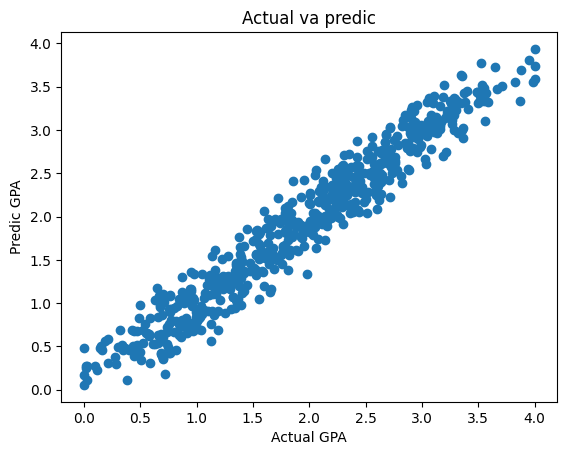

In [17]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel('Actual GPA')
plt.ylabel('Predic GPA')
plt.title('Actual va predic')

plt.show()